Found 1 face(s) in the image!


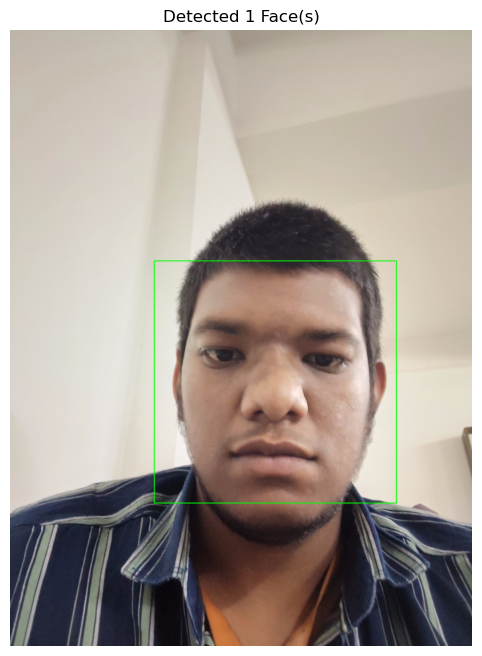

In [9]:
import cv2
import matplotlib.pyplot as plt

def detect_and_display_faces(image_path):
    """
    Loads an image, detects faces using OpenCV Haar Cascades, 
    and displays the result using Matplotlib (Jupyter safe).
    """
    # 1. Load the image from the specified path
    img = cv2.imread(image_path)
    
    # Check if the image was successfully loaded
    if img is None:
        print(f"Error: Could not load image at '{image_path}'. Please check the path.")
        return

    # 2. Convert the image from BGR (OpenCV default) to RGB (Matplotlib default)
    # This ensures the colors look normal when we display it later
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # 3. Convert the image to Grayscale
    # Face detection works much faster and more accurately on grayscale images
    gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 4. Load the pre-trained Haar Cascade classifier for frontal faces
    # cv2.data.haarcascades points to the directory where OpenCV stores these pre-trained XML files
    cascade_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
    face_cascade = cv2.CascadeClassifier(cascade_path)

    # 5. Detect faces in the grayscale image
    # scaleFactor: Parameter specifying how much the image size is reduced at each image scale
    # minNeighbors: Parameter specifying how many neighbors each candidate rectangle should have to retain it
    faces = face_cascade.detectMultiScale(
        gray_img, 
        scaleFactor=1.1, 
        minNeighbors=5, 
        minSize=(30, 30)
    )

    print(f"Found {len(faces)} face(s) in the image!")

    # 6. Draw a rectangle around every face detected
    for (x, y, w, h) in faces:
        # cv2.rectangle(image, start_point, end_point, color(RGB), thickness)
        cv2.rectangle(img_rgb, (x, y), (x+w, y+h), (0, 255, 0), 4)

    # 7. Display the image inline using Matplotlib
    plt.figure(figsize=(10, 8)) # Set the size of the displayed image
    plt.imshow(img_rgb)
    plt.axis('off') # Hide the axes ticks
    plt.title(f'Detected {len(faces)} Face(s)')
    plt.show()

# ==========================================
# How to run this in your Jupyter Notebook:
# ==========================================
# 1. Copy this entire script into a single cell.
# 2. Change 'your_image.jpg' to the actual path of an image on your computer.
#    (e.g., 'sample_faces.png' or 'C:/Users/Name/Pictures/photo.jpg')

image_file = 'lokesh.jpg' 
detect_and_display_faces(image_file)